# Creating Numbers/images with AI: A Hands-on Diffusion Model Exercise

## Introduction
In this assignment, you'll learn how to create an AI model that can generate realistic images from scratch using a powerful technique called 'diffusion'. Think of it like teaching AI to draw by first learning how images get blurry and then learning to make them clear again.

### What We'll Build
- A diffusion model capable of generating realistic images
- For most students: An AI that generates handwritten digits (0-9) using the MNIST dataset
- For students with more computational resources: Options to work with more complex datasets
- Visual demonstrations of how random noise gradually transforms into clear, recognizable images
- By the end, your AI should create images realistic enough for another AI to recognize them

### Dataset Options
This lab offers flexibility based on your available computational resources:

- Standard Option (Free Colab): We'll primarily use the MNIST handwritten digit dataset, which works well with limited GPU memory and completes training in a reasonable time frame. Most examples and code in this notebook are optimized for MNIST.

- Advanced Option: If you have access to more powerful GPUs (either through Colab Pro/Pro+ or your own hardware), you can experiment with more complex datasets like Fashion-MNIST, CIFAR-10, or even face generation. You'll need to adapt the model architecture, hyperparameters, and evaluation metrics accordingly.

### Resource Requirements
- Basic MNIST: Works with free Colab GPUs (2-4GB VRAM), ~30 minutes training
- Fashion-MNIST: Similar requirements to MNIST
CIFAR-10: Requires more memory (8-12GB VRAM) and longer training (~2 hours)
- Higher resolution images: Requires substantial GPU resources and several hours of training

### Before You Start
1. Make sure you're running this in Google Colab or another environment with GPU access
2. Go to 'Runtime' → 'Change runtime type' and select 'GPU' as your hardware accelerator
3. Each code cell has comments explaining what it does
4. Don't worry if you don't understand every detail - focus on the big picture!
5. If working with larger datasets, monitor your GPU memory usage carefully

The concepts you learn with MNIST will scale to more complex datasets, so even if you're using the basic option, you'll gain valuable knowledge about generative AI that applies to more advanced applications.



## Step 1: Setting Up Our Tools
First, let's install and import all the tools we need. Run this cell and wait for it to complete.

In [45]:
# Step 1: Install required packages
%pip install einops
print("Package installation complete.")

# Step 2: Import libraries
# --- Core PyTorch libraries ---
import torch  # Main deep learning framework
import torch.nn.functional as F  # Neural network functions like activation functions
import torch.nn as nn  # Neural network building blocks (layers)
from torch.optim import Adam  # Optimization algorithm for training

# --- Data handling ---
from torch.utils.data import Dataset, DataLoader, random_split  # For organizing and loading our data
import torchvision  # Library for computer vision datasets and models
import torchvision.transforms as transforms  # For preprocessing images

# --- Tensor manipulation ---
import random  # For random operations
from einops.layers.torch import Rearrange  # For reshaping tensors in neural networks
from einops import rearrange  # For elegant tensor reshaping operations
import numpy as np  # For numerical operations on arrays

# --- System utilities ---
import os  # For operating system interactions (used for CPU count)

# --- Visualization tools ---
import matplotlib.pyplot as plt  # For plotting images and graphs
from PIL import Image  # For image processing
from torchvision.utils import save_image, make_grid  # For saving and displaying image grids

# Step 3: Set up device (GPU or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"We'll be using: {device}")

# Check if we're actually using GPU (for students to verify)
if device.type == "cuda":
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("Note: Training will be much slower on CPU. Consider using Google Colab with GPU enabled.")

Package installation complete.
We'll be using: cuda
GPU name: Tesla T4
GPU memory: 15.64 GB



###  REPRODUCIBILITY AND DEVICE SETUP

In [46]:
# Step 4: Set random seeds for reproducibility
# Diffusion models are sensitive to initialization, so reproducible results help with debugging
SEED = 42  # Universal seed value for reproducibility
torch.manual_seed(SEED)          # PyTorch random number generator
np.random.seed(SEED)             # NumPy random number generator
random.seed(SEED)                # Python's built-in random number generator

print(f"Random seeds set to {SEED} for reproducible results")

# Configure CUDA for GPU operations if available
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)       # GPU random number generator
    torch.cuda.manual_seed_all(SEED)   # All GPUs random number generator

    # Ensure deterministic GPU operations
    # Note: This slightly reduces performance but ensures results are reproducible
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    try:
        # Check available GPU memory
        gpu_memory = torch.cuda.get_device_properties(0).total_memory / 1e9  # Convert to GB
        print(f"Available GPU Memory: {gpu_memory:.1f} GB")

        # Add recommendation based on memory
        if gpu_memory < 4:
            print("Warning: Low GPU memory. Consider reducing batch size if you encounter OOM errors.")
    except Exception as e:
        print(f"Could not check GPU memory: {e}")
else:
    print("No GPU detected. Training will be much slower on CPU.")
    print("If you're using Colab, go to Runtime > Change runtime type and select GPU.")

Random seeds set to 42 for reproducible results
Available GPU Memory: 15.6 GB


## Step 2: Choosing Your Dataset

You have several options for this exercise, depending on your computer's capabilities:

### Option 1: MNIST (Basic - Works on Free Colab)
- Content: Handwritten digits (0-9)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You're using free Colab or have a basic GPU

### Option 2: Fashion-MNIST (Intermediate)
- Content: Clothing items (shirts, shoes, etc.)
- Image size: 28x28 pixels, Grayscale
- Training samples: 60,000
- Memory needed: ~2GB GPU
- Training time: ~15-30 minutes on Colab
- **Choose this if**: You want more interesting images but have limited GPU

### Option 3: CIFAR-10 (Advanced)
- Content: Real-world objects (cars, animals, etc.)
- Image size: 32x32 pixels, Color (RGB)
- Training samples: 50,000
- Memory needed: ~4GB GPU
- Training time: ~1-2 hours on Colab
- **Choose this if**: You have Colab Pro or a good local GPU (8GB+ memory)

### Option 4: CelebA (Expert)
- Content: Celebrity face images
- Image size: 64x64 pixels, Color (RGB)
- Training samples: 200,000
- Memory needed: ~8GB GPU
- Training time: ~3-4 hours on Colab
- **Choose this if**: You have excellent GPU (12GB+ memory)

To use your chosen dataset, uncomment its section in the code below and make sure all others are commented out.

In [47]:
#===============================================================================
# SECTION 2: DATASET SELECTION AND CONFIGURATION
#===============================================================================
# STUDENT INSTRUCTIONS:
# 1. Choose ONE dataset option based on your available GPU memory
# 2. Uncomment ONLY ONE dataset section below
# 3. Make sure all other dataset sections remain commented out

#-------------------------------------------
# OPTION 1: MNIST (Basic - 2GB GPU)
#-------------------------------------------
# Recommended for: Free Colab or basic GPU
# Memory needed: ~2GB GPU
# Training time: ~15-30 minutes

IMG_SIZE = 28
IMG_CH = 1
N_CLASSES = 10
BATCH_SIZE = 64
EPOCHS = 10

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Your code to load the MNIST dataset
# Hint: Use torchvision.datasets.MNIST with root='./data', train=True,
#       transform=transform, and download=True
# Then print a success message

# Enter your code here:
train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

dataset = train_dataset # Assign train_dataset to dataset for validation

print("MNIST dataset loaded successfully!")
print(f"Number of training samples: {len(train_dataset)}")



MNIST dataset loaded successfully!
Number of training samples: 60000


In [48]:
#Validating Dataset Selection
#Let's add code to validate that a dataset was selected
# and check if your GPU has enough memory:

# Validate dataset selection
if 'dataset' not in locals():
    raise ValueError("""
    ❌ ERROR: No dataset selected! Please uncomment exactly one dataset option.
    Available options:
    1. MNIST (Basic) - 2GB GPU
    2. Fashion-MNIST (Intermediate) - 2GB GPU
    3. CIFAR-10 (Advanced) - 4GB+ GPU
    4. CelebA (Expert) - 8GB+ GPU
    """)

# Your code to validate GPU memory requirements
# Hint: Check torch.cuda.is_available() and use torch.cuda.get_device_properties(0).total_memory
# to get available GPU memory, then compare with dataset requirements

# Enter your code here:
if torch.cuda.is_available():
    total_memory = torch.cuda.get_device_properties(0).total_memory / (1024**3)
    print(f"✅ GPU: {torch.cuda.get_device_properties(0).name}")
    print(f"✅ Memory: {total_memory:.2f} GB")

    if total_memory < 2:
        raise ValueError("❌ Not enough GPU memory! Minimum 2GB required.")
else:
    print("⚠️ No GPU detected, running on CPU")

✅ GPU: Tesla T4
✅ Memory: 14.56 GB


In [49]:
#Dataset Properties and Data Loaders
#Now let's examine our dataset
#and set up the data loaders:

# Your code to check sample batch properties
# Hint: Get a sample batch using next(iter(DataLoader(dataset, batch_size=1)))
# Then print information about the dataset shape, type, and value ranges

# Enter your code here:
# Check sample batch properties
sample = next(iter(DataLoader(train_dataset, batch_size=1)))
images, labels = sample
print(f"Image shape: {images.shape}")
print(f"Data type: {images.dtype}")
print(f"Value range: [{images.min():.2f}, {images.max():.2f}]")
print(f"Total samples: {len(train_dataset)}")

#===============================================================================
# SECTION 3: DATASET SPLITTING AND DATALOADER CONFIGURATION
#===============================================================================
# Create train-validation split

# Your code to create a train-validation split (80% train, 20% validation)
# Hint: Use random_split() with appropriate train_size and val_size
# Be sure to use a fixed generator for reproducibility

# Enter your code here:
# Train-validation split (80/20)
train_size = int(0.8 * len(train_dataset))
val_size = len(train_dataset) - train_size
train_data, val_data = random_split(
    train_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)
print(f"Train size: {len(train_data)} | Val size: {len(val_data)}")


# Your code to create dataloaders for training and validation
# Hint: Use DataLoader with batch_size=BATCH_SIZE, appropriate shuffle settings,
# and num_workers based on available CPU cores

# Enter your code here:
# Create DataLoaders
num_workers = os.cpu_count() // 2
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True, num_workers=num_workers)
val_loader = DataLoader(val_data, batch_size=BATCH_SIZE, shuffle=False, num_workers=num_workers)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)}")

Image shape: torch.Size([1, 1, 28, 28])
Data type: torch.float32
Value range: [-1.00, 1.00]
Total samples: 60000
Train size: 48000 | Val size: 12000
Train batches: 750 | Val batches: 188


## Step 3: Building Our Model Components

Now we'll create the building blocks of our AI model. Think of these like LEGO pieces that we'll put together to make our number generator:

- GELUConvBlock: The basic building block that processes images
- DownBlock: Makes images smaller while finding important features
- UpBlock: Makes images bigger again while keeping the important features
- Other blocks: Help the model understand time and what number to generate

In [50]:
# Basic building block that processes images
class GELUConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, group_size):
        super().__init__()

        # Check that group_size is compatible with out_ch
        if out_ch % group_size != 0:
            print(f"Warning: out_ch ({out_ch}) is not divisible by group_size ({group_size})")
            # Adjust group_size to be compatible
            group_size = min(group_size, out_ch)
            while out_ch % group_size != 0:
                group_size -= 1
            print(f"Adjusted group_size to {group_size}")

        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.GroupNorm(group_size, out_ch),
            nn.GELU()
        )


    def forward(self, x):
      return self.block(x)

In [51]:
# Rearranges pixels to downsample the image (2x reduction in spatial dimensions)
class RearrangePoolBlock(nn.Module):
    def __init__(self, in_chs, group_size):
        super().__init__()

        # Rearrange pixels into channels
        self.rearrange = Rearrange('b c (h p1) (w p2) -> b (c p1 p2) h w', p1=2, p2=2)

        # Process rearranged tensor (channels become 4x after rearrange)
        self.conv = GELUConvBlock(in_chs * 4, in_chs * 4, group_size)


    def forward(self, x):
      x = self.rearrange(x)
      return self.conv(x)


In [52]:
#Let's implement the upsampling block for our U-Net architecture:
class DownBlock(nn.Module):
    def __init__(self, in_chs, out_chs, group_size):
        super().__init__()  # Simplified super() call, equivalent to original

        # Sequential processing of features
        layers = [
            GELUConvBlock(in_chs, out_chs, group_size),  # First conv block changes channel dimensions
            GELUConvBlock(out_chs, out_chs, group_size),  # Second conv block processes features
            RearrangePoolBlock(out_chs, group_size)       # Downsampling (spatial dims: H,W → H/2,W/2)
        ]
        self.model = nn.Sequential(*layers)

        # Log the configuration for debugging
        print(f"Created DownBlock: in_chs={in_chs}, out_chs={out_chs}, spatial_reduction=2x")

    def forward(self, x):
        return self.model(x)

In [53]:
# Modified UpBlock to handle dynamic channel concatenation
class UpBlock(nn.Module):
    def __init__(self, in_chs, skip_chs, group_size):
        super().__init__()
        # Upsample the incoming features from the lower layer
        self.up = nn.ConvTranspose2d(in_chs, in_chs, kernel_size=2, stride=2)

        # The input to the first conv block is exactly the sum of upsampled and skip channels
        combined_chs = in_chs + skip_chs

        self.conv = nn.Sequential(
            GELUConvBlock(combined_chs, skip_chs, group_size),
            GELUConvBlock(skip_chs, skip_chs, group_size)
        )
        print(f"Created UpBlock: processing {in_chs} (up) + {skip_chs} (skip) = {combined_chs} total")

    def forward(self, x, skip):
        x = self.up(x)                    # [B, in_chs, 2H, 2W]
        x = torch.cat([x, skip], dim=1)   # [B, in_chs + skip_chs, 2H, 2W]
        return self.conv(x)

In [54]:
# Here we implement the time embedding block for our U-Net architecture:
# Helps the model understand time steps in diffusion process
class SinusoidalPositionEmbedBlock(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = torch.log(torch.tensor(10000.0, device=device)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings



In [55]:
# Helps the model understand which number/image to draw (class conditioning)
class EmbedBlock(nn.Module):
    def __init__(self, input_dim, emb_dim):
        super(EmbedBlock, self).__init__()
        self.input_dim = input_dim

        # Your code to create the embedding layers
        # Hint: Use nn.Linear layers with a GELU activation, followed by
        # nn.Unflatten to reshape for broadcasting with feature maps

        # Enter your code here:
        self.model = nn.Sequential(
            nn.Linear(input_dim, emb_dim),
            nn.GELU(),
            nn.Linear(emb_dim, emb_dim),
            nn.Unflatten(1, (emb_dim, 1, 1))  # Reshape for broadcasting
        )
    def forward(self, x):
        x = x.view(-1, self.input_dim)
        return self.model(x)



In [56]:
class UNet(nn.Module):
    def __init__(self, T, img_ch, img_size, down_chs, t_embed_dim, c_embed_dim):
        super().__init__()
        self.t_embed = nn.Sequential(
            SinusoidalPositionEmbedBlock(t_embed_dim),
            nn.Linear(t_embed_dim, t_embed_dim),
            nn.GELU()
        )

        self.init_conv = GELUConvBlock(img_ch, down_chs[0], group_size=8)

        self.down_blocks = nn.ModuleList()
        curr_chs = down_chs[0]
        # Track channel sizes for skip connections accurately
        self.skip_chs_list = []

        for i in range(len(down_chs) - 1):
            self.down_blocks.append(RearrangePoolBlock(curr_chs, group_size=8))
            self.skip_chs_list.append(curr_chs) # Save channel count of skip
            curr_chs = curr_chs * 4

        self.mid1 = GELUConvBlock(curr_chs, curr_chs, group_size=8)
        self.mid2 = GELUConvBlock(curr_chs, curr_chs, group_size=8)
        self.t_proj = nn.Linear(t_embed_dim, curr_chs)
        self.c_embed = EmbedBlock(c_embed_dim, curr_chs)

        self.up_blocks = nn.ModuleList()
        # Walk backwards through the skip list
        for i in range(len(self.skip_chs_list) - 1, -1, -1):
            skip_ch = self.skip_chs_list[i]
            self.up_blocks.append(UpBlock(curr_chs, skip_ch, group_size=8))
            curr_chs = skip_ch

        self.final_conv = nn.Conv2d(curr_chs, img_ch, kernel_size=1)

    def forward(self, x, t, c, c_mask):
        t_emb = self.t_embed(t)
        c_emb = self.c_embed(c) * c_mask.view(-1, 1, 1, 1)
        x = self.init_conv(x)
        skips = []
        for down in self.down_blocks:
            skips.append(x)
            x = down(x)
        x = self.mid1(x)
        x = self.mid2(x)
        t_spatial = self.t_proj(t_emb).view(-1, x.shape[1], 1, 1)
        x = x + t_spatial + c_emb
        for up in self.up_blocks:
            x = up(x, skips.pop())
        return self.final_conv(x)

## Step 4: Setting Up The Diffusion Process

Now we'll create the process of adding and removing noise from images. Think of it like:
1. Adding fog: Slowly making the image more and more blurry until you can't see it
2. Removing fog: Teaching the AI to gradually make the image clearer
3. Controlling the process: Making sure we can generate specific numbers we want

In [57]:
# Set up the noise schedule
n_steps = 100  # How many steps to go from clear image to noise
beta_start = 0.0001  # Starting noise level (small)
beta_end = 0.02      # Ending noise level (larger)

# Create schedule of gradually increasing noise levels
beta = torch.linspace(beta_start, beta_end, n_steps).to(device)

# Calculate important values used in diffusion equations
alpha = 1 - beta  # Portion of original image to keep at each step
alpha_bar = torch.cumprod(alpha, dim=0)  # Cumulative product of alphas
sqrt_alpha_bar = torch.sqrt(alpha_bar)  # For scaling the original image
sqrt_one_minus_alpha_bar = torch.sqrt(1 - alpha_bar)  # For scaling the noise


In [58]:
# Function to add noise to images (forward diffusion process)
def add_noise(x_0, t):
    # Create random Gaussian noise with same shape as image
    noise = torch.randn_like(x_0)

    # Get noise schedule values for the specified timesteps
    # Reshape to allow broadcasting with image dimensions
    sqrt_alpha_bar_t = sqrt_alpha_bar[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Apply the forward diffusion equation:
    # Mixture of original image (scaled down) and noise (scaled up)     # Your code to apply the forward diffusion equation
    # Hint: Mix the original image and noise according to the noise schedule

    # Enter your code here:
    x_t = sqrt_alpha_bar_t * x_0 + sqrt_one_minus_alpha_bar_t * noise
    return x_t, noise

In [59]:
# Function to remove noise from images (reverse diffusion process)
@torch.no_grad()  # Don't track gradients during sampling (inference only)
def remove_noise(x_t, t, model, c, c_mask):
    # Predict the noise in the image using our model
    predicted_noise = model(x_t, t, c, c_mask)

    # Get noise schedule values for the current timestep
    alpha_t = alpha[t].reshape(-1, 1, 1, 1)
    alpha_bar_t = alpha_bar[t].reshape(-1, 1, 1, 1)
    beta_t = beta[t].reshape(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = sqrt_one_minus_alpha_bar[t].reshape(-1, 1, 1, 1)

    # Special case: if we're at the first timestep (t=0), we're done
    if t[0] == 0:
        return x_t
    else:
        # Calculate the mean of the denoised distribution
        # This is derived from Bayes' rule and the diffusion process equations
        mean = (1 / torch.sqrt(alpha_t)) * (
            x_t - (beta_t / sqrt_one_minus_alpha_bar_t) * predicted_noise
        )

        # Add a small amount of random noise (variance depends on timestep)
        # This helps prevent the generation from becoming too deterministic
        noise = torch.randn_like(x_t)

        # Return the partially denoised image with a bit of new random noise
        return mean + torch.sqrt(beta_t) * noise

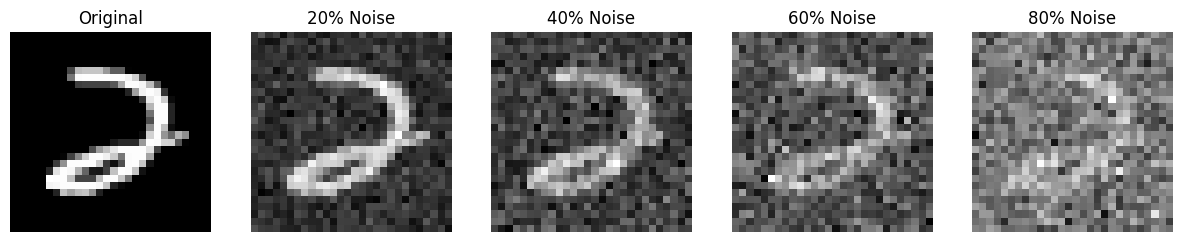

'\n# Try a non-linear noise schedule\nbeta_alt = torch.linspace(beta_start, beta_end, n_steps)**2\nalpha_alt = 1 - beta_alt\nalpha_bar_alt = torch.cumprod(alpha_alt, dim=0)\n# How would this affect the diffusion process?\n'

In [60]:
# Visualization function to show how noise progressively affects images
def show_noise_progression(image, num_steps=5):
    plt.figure(figsize=(15, 3))

    # Show original image
    plt.subplot(1, num_steps, 1)
    if IMG_CH == 1:  # Grayscale image
        plt.imshow(image[0].cpu(), cmap='gray')
    else:  # Color image
        img = image.permute(1, 2, 0).cpu()  # Change from [C,H,W] to [H,W,C]
        if img.min() < 0:  # If normalized between -1 and 1
            img = (img + 1) / 2  # Rescale to [0,1] for display
        plt.imshow(img)
    plt.title('Original')
    plt.axis('off')

    # Show progressively noisier versions
    for i in range(1, num_steps):
        # Calculate timestep index based on percentage through the process
        t_idx = int((i/num_steps) * n_steps)
        t = torch.tensor([t_idx]).to(device)

        # Add noise corresponding to timestep t
        noisy_image, _ = add_noise(image.unsqueeze(0), t)

        # Display the noisy image
        plt.subplot(1, num_steps, i+1)
        if IMG_CH == 1:
            plt.imshow(noisy_image[0][0].cpu(), cmap='gray')
        else:
            img = noisy_image[0].permute(1, 2, 0).cpu()
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)
        plt.title(f'{int((i/num_steps) * 100)}% Noise')
        plt.axis('off')
    plt.show()

# Show an example of noise progression on a real image
sample_batch = next(iter(train_loader))  # Get first batch
sample_image = sample_batch[0][0].to(device)  # Get first image
show_noise_progression(sample_image)

# Student Activity: Try different noise schedules
# Uncomment and modify these lines to experiment:
"""
# Try a non-linear noise schedule
beta_alt = torch.linspace(beta_start, beta_end, n_steps)**2
alpha_alt = 1 - beta_alt
alpha_bar_alt = torch.cumprod(alpha_alt, dim=0)
# How would this affect the diffusion process?
"""

## Step 5: Training Our Model

Now we'll teach our AI to generate images. This process:
1. Takes a clear image
2. Adds random noise to it
3. Asks our AI to predict what noise was added
4. Helps our AI learn from its mistakes

This will take a while, but we'll see progress as it learns!

In [61]:
# Create our model and move it to GPU if available
model = UNet(
    T=n_steps,                 # Number of diffusion time steps
    img_ch=IMG_CH,             # Number of channels in our images (1 for grayscale, 3 for RGB)
    img_size=IMG_SIZE,         # Size of input images (28 for MNIST, 32 for CIFAR-10)
    down_chs=(32, 64, 128),    # Channel dimensions for each downsampling level
    t_embed_dim=8,             # Dimension for time step embeddings
    c_embed_dim=N_CLASSES      # Number of classes for conditioning
).to(device)

# Print model summary
print(f"\n{'='*50}")
print(f"MODEL ARCHITECTURE SUMMARY")
print(f"{'='*50}")
print(f"Input resolution: {IMG_SIZE}x{IMG_SIZE}")
print(f"Input channels: {IMG_CH}")
print(f"Time steps: {n_steps}")
print(f"Condition classes: {N_CLASSES}")
print(f"GPU acceleration: {'Yes' if device.type == 'cuda' else 'No'}")

def count_parameters(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Total parameters:     {total:,}")
    print(f"Trainable parameters: {trainable:,}")
    print(f"Estimated memory:     {total * 4 / (1024**2):.2f} MB")

count_parameters(model)

# Set up the optimizer
optimizer = Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5, min_lr=1e-6)

Created UpBlock: processing 512 (up) + 128 (skip) = 640 total
Created UpBlock: processing 128 (up) + 32 (skip) = 160 total

MODEL ARCHITECTURE SUMMARY
Input resolution: 28x28
Input channels: 1
Time steps: 100
Condition classes: 10
GPU acceleration: Yes
Total parameters:     9,559,465
Trainable parameters: 9,559,465
Estimated memory:     36.47 MB


In [62]:
# Define helper functions needed for training and evaluation
def validate_model_parameters(model):
    """
    Counts model parameters and estimates memory usage.
    """
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

    print(f"Total parameters: {total_params:,}")
    print(f"Trainable parameters: {trainable_params:,}")

    # Estimate memory requirements (very approximate)
    param_memory = total_params * 4 / (1024 ** 2)  # MB for params (float32)
    grad_memory = trainable_params * 4 / (1024 ** 2)  # MB for gradients
    buffer_memory = param_memory * 2  # Optimizer state, forward activations, etc.

    print(f"Estimated GPU memory usage: {param_memory + grad_memory + buffer_memory:.1f} MB")

# Define helper functions for verifying data ranges
def verify_data_range(dataloader, name="Dataset"):
    """
    Verifies the range and integrity of the data.
    """
    batch = next(iter(dataloader))[0]
    print(f"\n{name} range check:")
    print(f"Shape: {batch.shape}")
    print(f"Data type: {batch.dtype}")
    print(f"Min value: {batch.min().item():.2f}")
    print(f"Max value: {batch.max().item():.2f}")
    print(f"Contains NaN: {torch.isnan(batch).any().item()}")
    print(f"Contains Inf: {torch.isinf(batch).any().item()}")

# Define helper functions for generating samples during training
def generate_samples(model, n_samples=10):
    """
    Generates sample images using the model for visualization during training.
    """
    model.eval()
    with torch.no_grad():
        # Generate digits 0-9 for visualization
        samples = []
        for digit in range(min(n_samples, 10)):
            # Start with random noise
            x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

            # Set up conditioning for the digit
            c = torch.tensor([digit]).to(device)
            c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
            c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

            # Remove noise step by step
            for t in range(n_steps-1, -1, -1):
                t_batch = torch.full((1,), t).to(device)
                x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            samples.append(x)

        # Combine samples and display
        samples = torch.cat(samples, dim=0)
        grid = make_grid(samples, nrow=min(n_samples, 5), normalize=True)

        plt.figure(figsize=(10, 4))

        # Display based on channel configuration
        if IMG_CH == 1:
            plt.imshow(grid[0].cpu(), cmap='gray')
        else:
            plt.imshow(grid.permute(1, 2, 0).cpu())

        plt.axis('off')
        plt.title('Generated Samples')
        plt.show()

# Define helper functions for safely saving models
def safe_save_model(model, path, optimizer=None, epoch=None, best_loss=None):
    """
    Safely saves model with error handling and backup.
    """
    try:
        # Create a dictionary with all the elements to save
        save_dict = {
            'model_state_dict': model.state_dict(),
        }

        # Add optional elements if provided
        if optimizer is not None:
            save_dict['optimizer_state_dict'] = optimizer.state_dict()
        if epoch is not None:
            save_dict['epoch'] = epoch
        if best_loss is not None:
            save_dict['best_loss'] = best_loss

        # Create a backup of previous checkpoint if it exists
        if os.path.exists(path):
            backup_path = path + '.backup'
            try:
                os.replace(path, backup_path)
                print(f"Created backup at {backup_path}")
            except Exception as e:
                print(f"Warning: Could not create backup - {e}")

        # Save the new checkpoint
        torch.save(save_dict, path)
        print(f"Model successfully saved to {path}")

    except Exception as e:
        print(f"Error saving model: {e}")
        print("Attempting emergency save...")

        try:
            emergency_path = path + '.emergency'
            torch.save(model.state_dict(), emergency_path)
            print(f"Emergency save successful: {emergency_path}")
        except:
            print("Emergency save failed. Could not save model.")

# Run validation checks
validate_model_parameters(model)
verify_data_range(train_loader, "Train")
verify_data_range(val_loader, "Val")

Total parameters: 9,559,465
Trainable parameters: 9,559,465
Estimated GPU memory usage: 145.9 MB

Train range check:
Shape: torch.Size([64, 1, 28, 28])
Data type: torch.float32
Min value: -1.00
Max value: 1.00
Contains NaN: False
Contains Inf: False

Val range check:
Shape: torch.Size([64, 1, 28, 28])
Data type: torch.float32
Min value: -1.00
Max value: 1.00
Contains NaN: False
Contains Inf: False


In [63]:
#  Implementation of the training step function
def train_step(x, c):
    # Convert number labels to one-hot encoding for class conditioning
    # Example: Label 3 -> [0, 0, 0, 1, 0, 0, 0, 0, 0, 0] for MNIST
    c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)

    # Create conditioning mask (all ones for standard training)
    # This would be used for classifier-free guidance if implemented
    c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

    # Pick random timesteps for each image in the batch
    # Different timesteps allow the model to learn the entire diffusion process
    t = torch.randint(0, n_steps, (x.shape[0],)).to(device)

    # Add noise to images according to the forward diffusion process
    # This simulates images at different stages of the diffusion process
    # Hint: Use the add_noise function you defined earlier

    # Enter your code here:
    x_t, noise = add_noise(x, t)

    # The model tries to predict the exact noise that was added
    # This is the core learning objective of diffusion models
    predicted_noise = model(x_t, t, c_one_hot, c_mask)

    # Calculate loss: how accurately did the model predict the noise?
    # MSE loss works well for image-based diffusion models
    # Hint: Use F.mse_loss to compare predicted and actual noise

    # Enter your code here:
    return F.mse_loss(predicted_noise, noise)


In [64]:
# Implementation of the main training loop
early_stopping_patience = 10
gradient_clip_value = 1.0
display_frequency = 100

best_loss = float('inf')
train_losses = []
val_losses = []
no_improve_epochs = 0

print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

try:
    for epoch in range(EPOCHS):
        model.train()
        epoch_losses = []
        for step, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = train_step(images, labels)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=gradient_clip_value)
            optimizer.step()
            epoch_losses.append(loss.item())
            if step % display_frequency == 0:
                print(f"  Epoch {epoch+1}, Step {step}/{len(train_loader)}, Loss: {loss.item():.4f}")

        avg_train_loss = sum(epoch_losses) / len(epoch_losses)
        train_losses.append(avg_train_loss)

        model.eval()
        val_epoch_losses = []
        with torch.no_grad():
            for val_images, val_labels in val_loader:
                val_loss = train_step(val_images.to(device), val_labels.to(device))
                val_epoch_losses.append(val_loss.item())

        avg_val_loss = sum(val_epoch_losses) / len(val_epoch_losses)
        val_losses.append(avg_val_loss)
        scheduler.step(avg_val_loss)
        print(f"Epoch {epoch+1} summary: Train Loss {avg_train_loss:.4f}, Val Loss {avg_val_loss:.4f}")

        if avg_val_loss < best_loss:
            best_loss = avg_val_loss
            torch.save(model.state_dict(), 'best_diffusion_model.pt')
            no_improve_epochs = 0
        else:
            no_improve_epochs += 1
            if no_improve_epochs >= early_stopping_patience:
                print("Early stopping triggered!")
                break
except Exception as e:
    print(f"Training failed: {e}")
finally:
    print("TRAINING COMPLETE")


STARTING TRAINING
  Epoch 1, Step 0/750, Loss: 1.1665
  Epoch 1, Step 100/750, Loss: 0.1313
  Epoch 1, Step 200/750, Loss: 0.0950
  Epoch 1, Step 300/750, Loss: 0.0837
  Epoch 1, Step 400/750, Loss: 0.0928
  Epoch 1, Step 500/750, Loss: 0.0840
  Epoch 1, Step 600/750, Loss: 0.0817
  Epoch 1, Step 700/750, Loss: 0.0781
Epoch 1 summary: Train Loss 0.1064, Val Loss 0.0777
  Epoch 2, Step 0/750, Loss: 0.0742
  Epoch 2, Step 100/750, Loss: 0.0733
  Epoch 2, Step 200/750, Loss: 0.0704
  Epoch 2, Step 300/750, Loss: 0.0673
  Epoch 2, Step 400/750, Loss: 0.0681
  Epoch 2, Step 500/750, Loss: 0.0646
  Epoch 2, Step 600/750, Loss: 0.0630
  Epoch 2, Step 700/750, Loss: 0.0766
Epoch 2 summary: Train Loss 0.0718, Val Loss 0.0695
  Epoch 3, Step 0/750, Loss: 0.0692
  Epoch 3, Step 100/750, Loss: 0.0684
  Epoch 3, Step 200/750, Loss: 0.0848
  Epoch 3, Step 300/750, Loss: 0.0808
  Epoch 3, Step 400/750, Loss: 0.0583
  Epoch 3, Step 500/750, Loss: 0.0638
  Epoch 3, Step 600/750, Loss: 0.0702
  Epoch 3

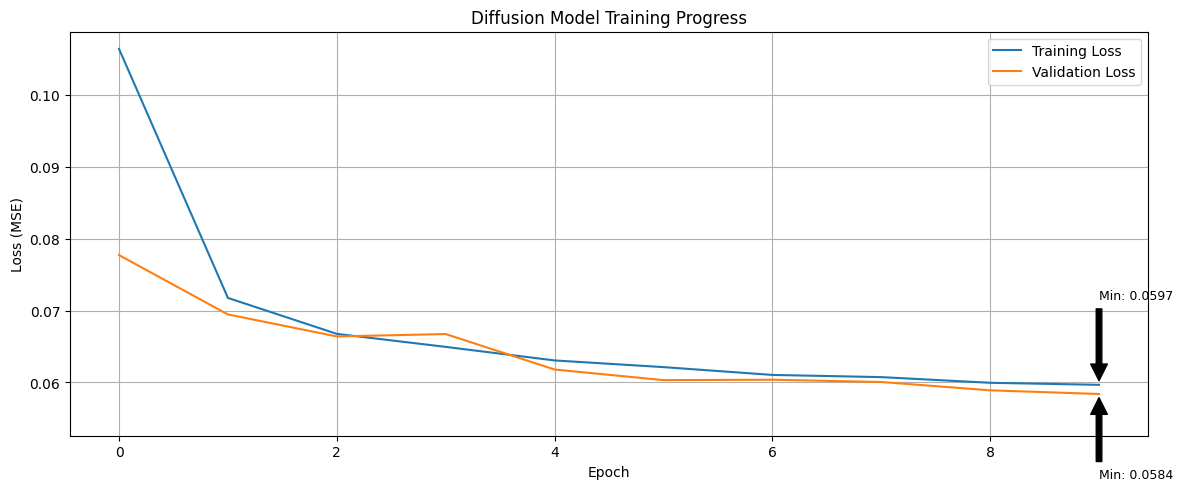


Training Statistics:
------------------------------
Starting training loss:    0.1064
Final training loss:       0.0597
Best training loss:        0.0597
Training loss improvement: 43.9%

Validation Statistics:
------------------------------
Starting validation loss: 0.0777
Final validation loss:    0.0584
Best validation loss:     0.0584


In [65]:
# Plot training progress
plt.figure(figsize=(12, 5))

# Plot training and validation losses for comparison
plt.plot(train_losses, label='Training Loss')
if len(val_losses) > 0:  # Only plot validation if it exists
    plt.plot(val_losses, label='Validation Loss')

# Improve the plot with better labels and styling
plt.title('Diffusion Model Training Progress')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)

# Add annotations for key points
if len(train_losses) > 1:
    min_train_idx = train_losses.index(min(train_losses))
    plt.annotate(f'Min: {min(train_losses):.4f}',
                 xy=(min_train_idx, min(train_losses)),
                 xytext=(min_train_idx, min(train_losses)*1.2),
                 arrowprops=dict(facecolor='black', shrink=0.05),
                 fontsize=9)

# Add validation min point if available
if len(val_losses) > 1:
    min_val_idx = val_losses.index(min(val_losses))
    plt.annotate(f'Min: {min(val_losses):.4f}',
                xy=(min_val_idx, min(val_losses)),
                xytext=(min_val_idx, min(val_losses)*0.8),
                arrowprops=dict(facecolor='black', shrink=0.05),
                fontsize=9)

# Set y-axis to start from 0 or slightly lower than min value
plt.ylim(bottom=max(0, min(min(train_losses) if train_losses else float('inf'),
                          min(val_losses) if val_losses else float('inf'))*0.9))

plt.tight_layout()
plt.show()

# Add statistics summary for students to analyze
print("\nTraining Statistics:")
print("-" * 30)
if train_losses:
    print(f"Starting training loss:    {train_losses[0]:.4f}")
    print(f"Final training loss:       {train_losses[-1]:.4f}")
    print(f"Best training loss:        {min(train_losses):.4f}")
    print(f"Training loss improvement: {((train_losses[0] - min(train_losses)) / train_losses[0] * 100):.1f}%")

if val_losses:
    print("\nValidation Statistics:")
    print("-" * 30)
    print(f"Starting validation loss: {val_losses[0]:.4f}")
    print(f"Final validation loss:    {val_losses[-1]:.4f}")
    print(f"Best validation loss:     {min(val_losses):.4f}")

# STUDENT EXERCISE:
# 1. Try modifying this plot to show a smoothed version of the losses
# 2. Create a second plot showing the ratio of validation to training loss
#    (which can indicate overfitting when the ratio increases)

## Step 6: Generating New Images

Now that our model is trained, let's generate some new images! We can:
1. Generate specific numbers
2. Generate multiple versions of each number
3. See how the generation process works step by step

Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 

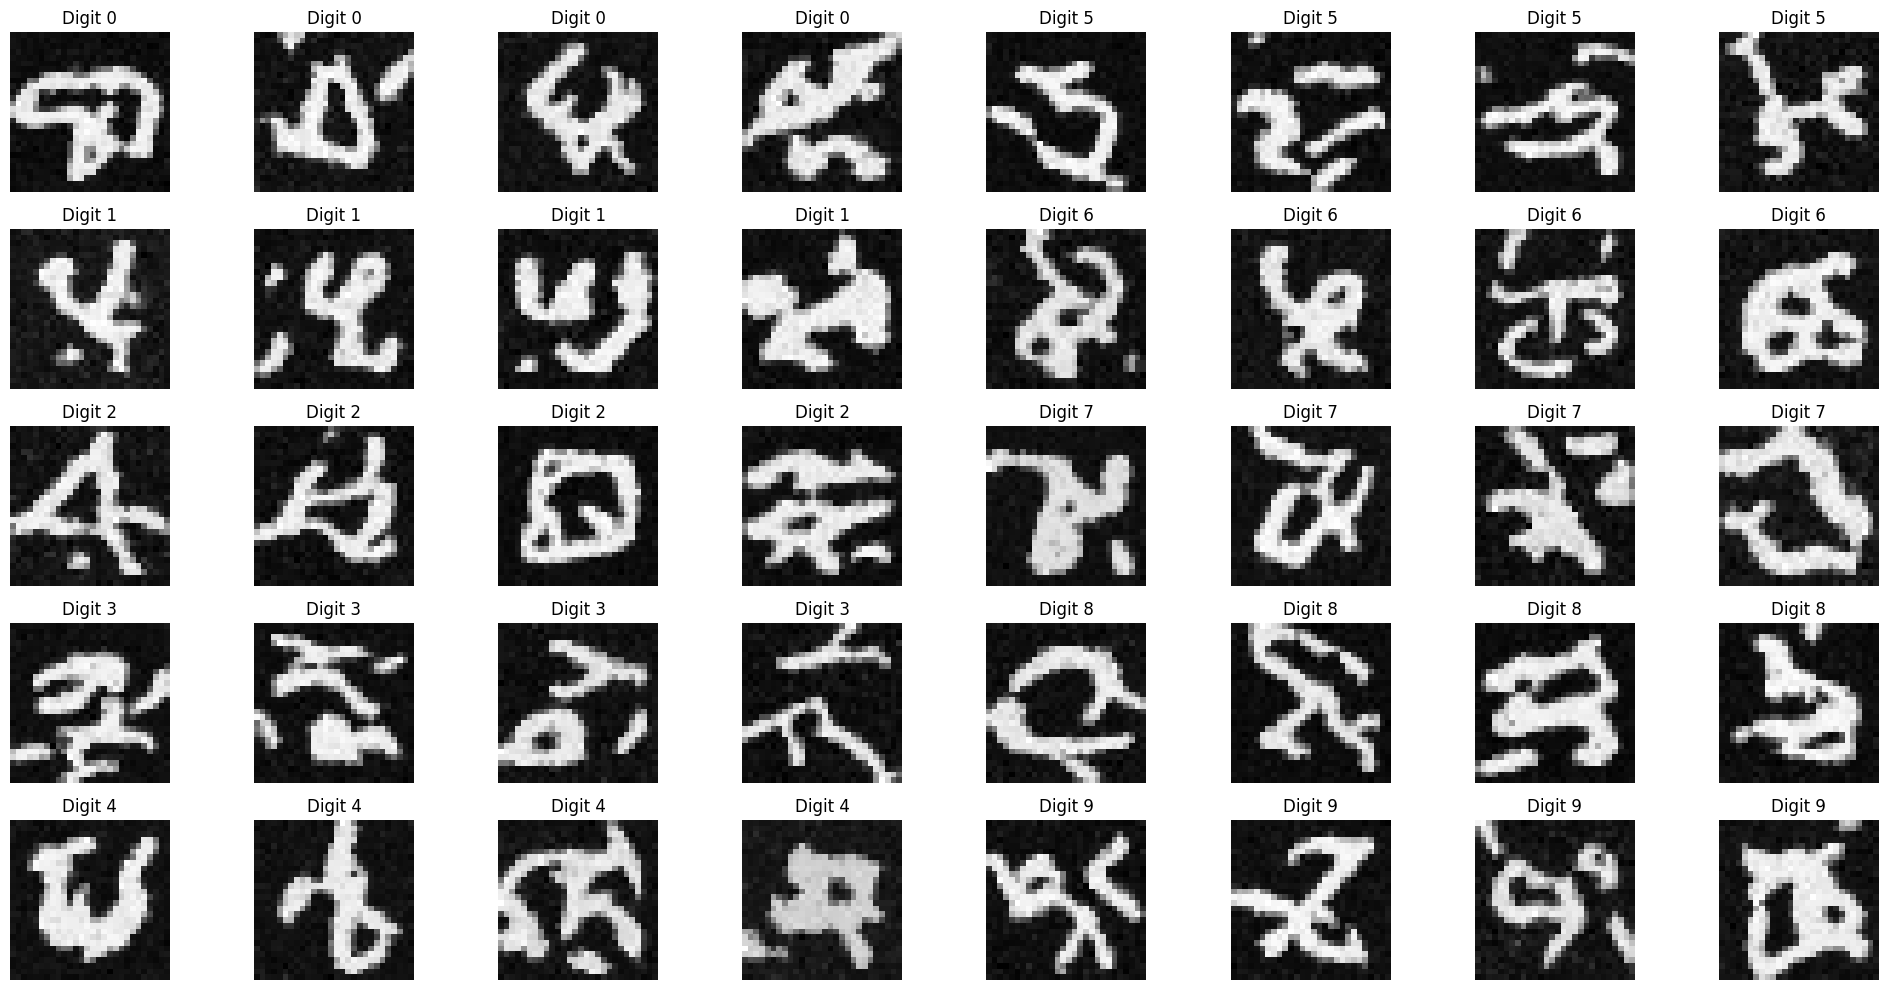


STUDENT ACTIVITY: Generating numbers with different noise seeds
Generating 10 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 10 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
Generating 10 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


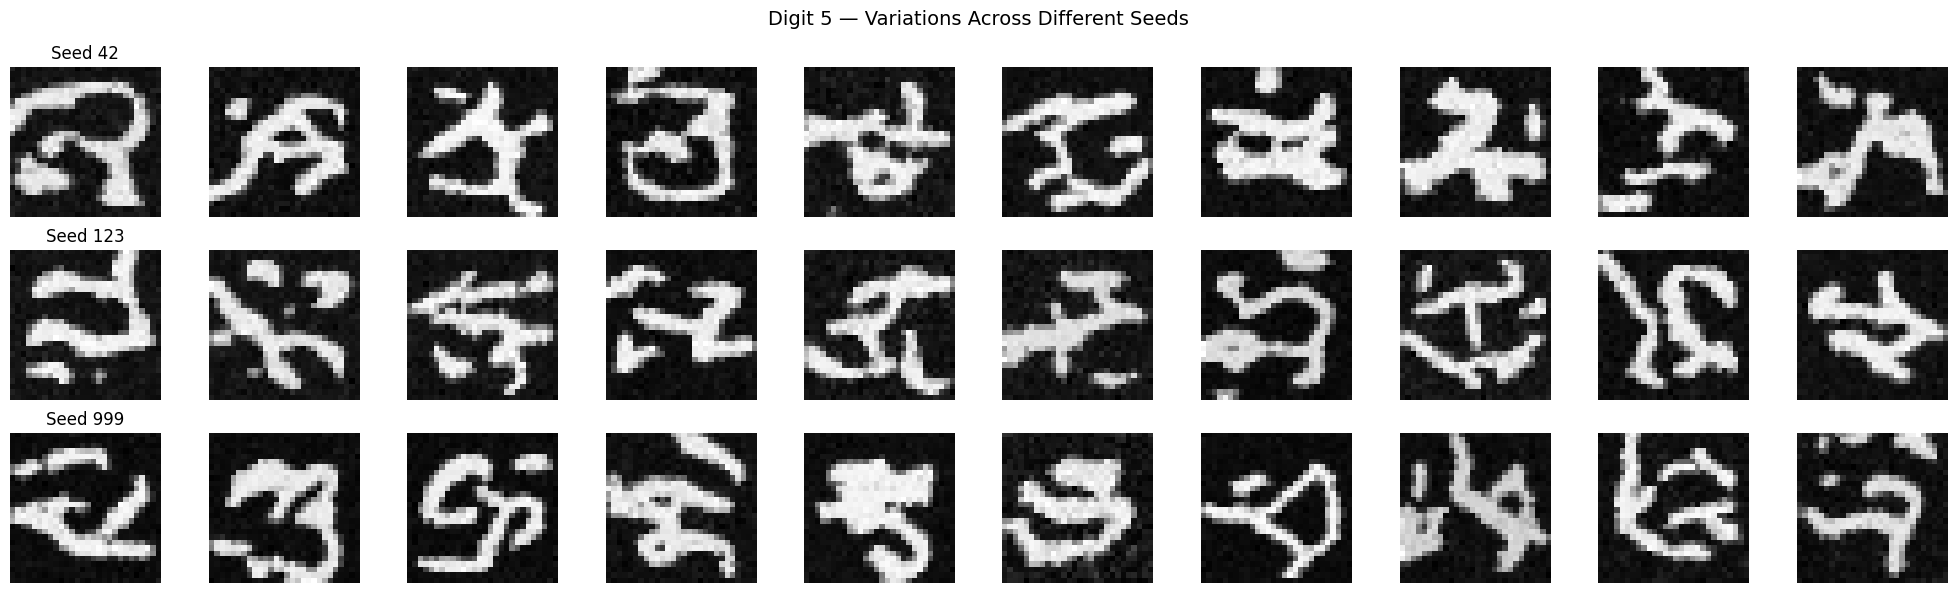

In [66]:
def generate_number(model, number, n_samples=4):
    model.eval()  # Set model to evaluation mode
    with torch.no_grad():  # No need for gradients during generation
        # Start with random noise
        samples = torch.randn(n_samples, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up the number we want to generate
        c = torch.full((n_samples,), number).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        # Correctly sized conditioning mask
        c_mask = torch.ones_like(c.unsqueeze(-1)).to(device)

        # Display progress information
        print(f"Generating {n_samples} versions of number {number}...")

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((n_samples,), t).to(device)
            samples = remove_noise(samples, t_batch, model, c_one_hot, c_mask)

            # Optional: Display occasional progress updates
            if t % (n_steps // 5) == 0:
                print(f"  Denoising step {n_steps-1-t}/{n_steps-1} completed")

        return samples

# Generate 4 versions of each number
plt.figure(figsize=(20, 10))
for i in range(10):
    # Generate samples for current digit
    samples = generate_number(model, i, n_samples=4)

    # Display each sample
    for j in range(4):
        # Use 2 rows, 10 digits per row, 4 samples per digit
        # i//5 determines the row (0 or 1)
        # i%5 determines the position in the row (0-4)
        # j is the sample index within each digit (0-3)
        plt.subplot(5, 8, (i%5)*8 + (i//5)*4 + j + 1)

        # Display the image correctly based on channel configuration
        if IMG_CH == 1:  # Grayscale
            plt.imshow(samples[j][0].cpu(), cmap='gray')
        else:  # Color image
            img = samples[j].permute(1, 2, 0).cpu()
            # Rescale from [-1, 1] to [0, 1] if needed
            if img.min() < 0:
                img = (img + 1) / 2
            plt.imshow(img)

        plt.title(f'Digit {i}')
        plt.axis('off')

plt.tight_layout()
plt.show()

# STUDENT ACTIVITY: Try generating the same digit with different noise seeds
# This shows the variety of styles the model can produce
print("\nSTUDENT ACTIVITY: Generating numbers with different noise seeds")

# Helper function to generate with seed
def generate_with_seed(number, seed_value=42, n_samples=10):
    torch.manual_seed(seed_value)
    return generate_number(model, number, n_samples)

# Generate 10 variations of digit 5 with different seeds
chosen_digit = 5  # Change this to any digit 0-9

fig, axes = plt.subplots(3, 10, figsize=(20, 6))
for idx, seed in enumerate([42, 123, 999]):
    variations = generate_with_seed(chosen_digit, seed_value=seed, n_samples=10)
    for j in range(10):
        axes[idx, j].imshow(variations[j][0].cpu(), cmap='gray')
        axes[idx, j].set_title(f'Seed {seed}' if j == 0 else '')
        axes[idx, j].axis('off')

plt.suptitle(f'Digit {chosen_digit} — Variations Across Different Seeds', fontsize=14)
plt.tight_layout()
plt.show()

## Step 7: Watching the Generation Process

Let's see how our model turns random noise into clear images, step by step. This helps us understand how the diffusion process works!


Generating number 0:


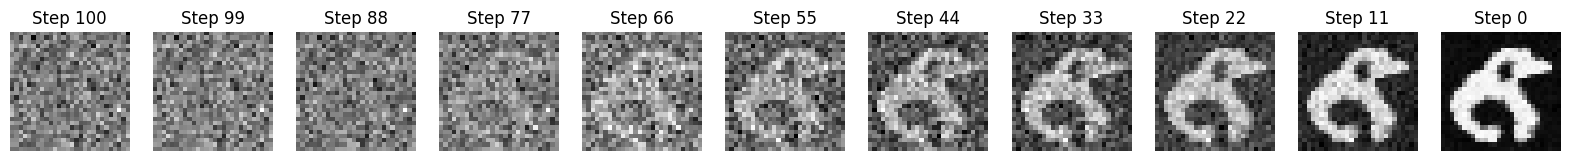


Generating number 3:


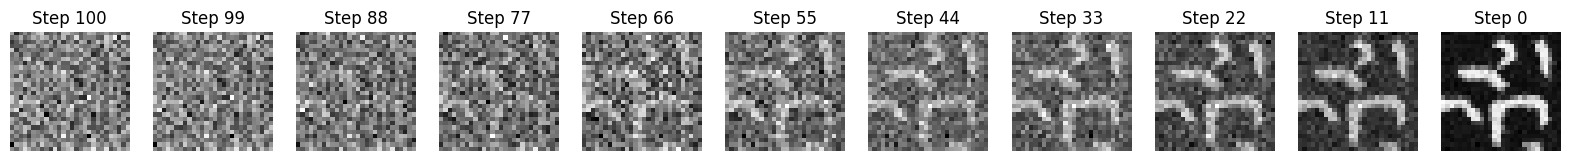


Generating number 7:


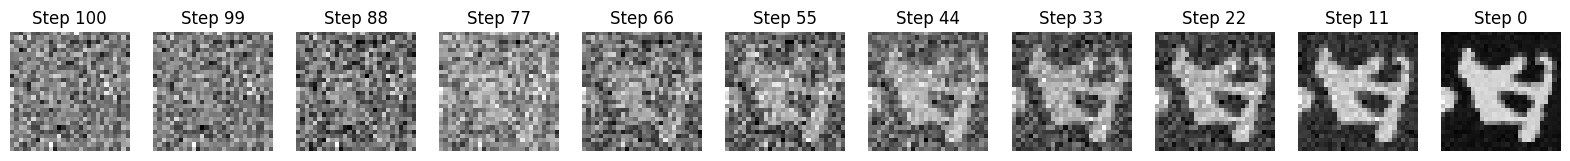

In [67]:
def visualize_generation_steps(model, number, n_preview_steps=10):
    """
    Show how an image evolves from noise to a clear number
    """
    model.eval()
    with torch.no_grad():
        # Start with random noise
        x = torch.randn(1, IMG_CH, IMG_SIZE, IMG_SIZE).to(device)

        # Set up which number to generate
        c = torch.tensor([number]).to(device)
        c_one_hot = F.one_hot(c, N_CLASSES).float().to(device)
        c_mask = torch.ones((1, 1)).to(device)

        # Calculate which steps to show
        steps_to_show = torch.linspace(n_steps-1, 0, n_preview_steps).long()

        # Store images for visualization
        images = []
        images.append(x[0].cpu())

        # Remove noise step by step
        for t in range(n_steps-1, -1, -1):
            t_batch = torch.full((1,), t).to(device)
            x = remove_noise(x, t_batch, model, c_one_hot, c_mask)

            if t in steps_to_show:
                images.append(x[0].cpu())

        # Show the progression
        plt.figure(figsize=(20, 3))
        for i, img in enumerate(images):
            plt.subplot(1, len(images), i+1)
            if IMG_CH == 1:
                plt.imshow(img[0], cmap='gray')
            else:
                img = img.permute(1, 2, 0)
                if img.min() < 0:
                    img = (img + 1) / 2
                plt.imshow(img)
            step = n_steps if i == 0 else steps_to_show[i-1]
            plt.title(f'Step {step}')
            plt.axis('off')
        plt.show()

# Show generation process for a few numbers
for number in [0, 3, 7]:
    print(f"\nGenerating number {number}:")
    visualize_generation_steps(model, number)

## Step 8: Adding CLIP Evaluation

[CLIP](https://openai.com/research/clip) is a powerful AI model that can understand both images and text. We'll use it to:
1. Evaluate how realistic our generated images are
2. Score how well they match their intended numbers
3. Help guide the generation process towards better quality

In [68]:
## Step 8: Adding CLIP Evaluation

# CLIP (Contrastive Language-Image Pre-training) is a powerful model by OpenAI that connects text and images.
# We'll use it to evaluate how recognizable our generated digits are by measuring how strongly
# the CLIP model associates our generated images with text descriptions like "an image of the digit 7".

# First, we need to install CLIP and its dependencies
print("Setting up CLIP (Contrastive Language-Image Pre-training) model...")

# Track installation status
clip_available = False

try:
    # Install dependencies first - these help CLIP process text and images
    print("Installing CLIP dependencies...")
    !pip install -q ftfy regex tqdm

    # Install CLIP from GitHub
    print("Installing CLIP from GitHub repository...")
    !pip install -q git+https://github.com/openai/CLIP.git

    # Import and verify CLIP is working
    print("Importing CLIP...")
    import clip

    # Test that CLIP is functioning
    models = clip.available_models()
    print(f"✓ CLIP installation successful! Available models: {models}")
    clip_available = True

except ImportError:
    print("❌ Error importing CLIP. Installation might have failed.")
    print("Try manually running: !pip install git+https://github.com/openai/CLIP.git")
    print("If you're in a Colab notebook, try restarting the runtime after installation.")

except Exception as e:
    print(f"❌ Error during CLIP setup: {e}")
    print("Some CLIP functionality may not work correctly.")

# Provide guidance based on installation result
if clip_available:
    print("\nCLIP is now available for evaluating your generated images!")
else:
    print("\nWARNING: CLIP installation failed. We'll skip the CLIP evaluation parts.")

# Import necessary libraries
import functools
import torch.nn.functional as F


Setting up CLIP (Contrastive Language-Image Pre-training) model...
Installing CLIP dependencies...
Installing CLIP from GitHub repository...
  Preparing metadata (setup.py) ... done
Importing CLIP...
✓ CLIP installation successful! Available models: ['RN50', 'RN101', 'RN50x4', 'RN50x16', 'RN50x64', 'ViT-B/32', 'ViT-B/16', 'ViT-L/14', 'ViT-L/14@336px']

CLIP is now available for evaluating your generated images!


 Below we are createing  a helper function to manage GPU memory when using CLIP. CLIP can be memory-intensive, so this will help prevent out-of-memory errors:

In [69]:
# Memory management decorator to prevent GPU OOM errors
def manage_gpu_memory(func):
    """
    Decorator that ensures proper GPU memory management.

    This wraps functions that might use large amounts of GPU memory,
    making sure memory is properly freed after function execution.
    """
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        if torch.cuda.is_available():
            # Clear cache before running function
            torch.cuda.empty_cache()
            try:
                return func(*args, **kwargs)
            finally:
                # Clear cache after running function regardless of success/failure
                torch.cuda.empty_cache()
        return func(*args, **kwargs)
    return wrapper

✓ Successfully loaded CLIP model: VisionTransformer

Generating and evaluating number 0...
Generating 4 versions of number 0...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


/tmp/ipykernel_1620/1839684446.py:77: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.no_grad(), torch.cuda.amp.autocast():


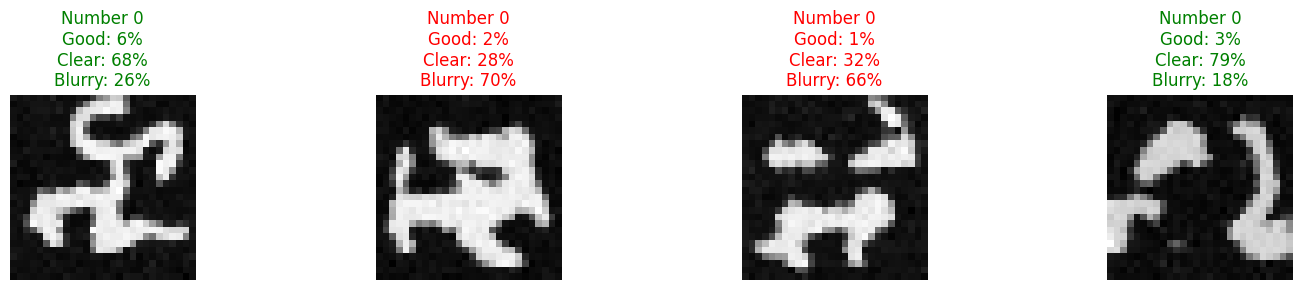


Generating and evaluating number 1...
Generating 4 versions of number 1...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


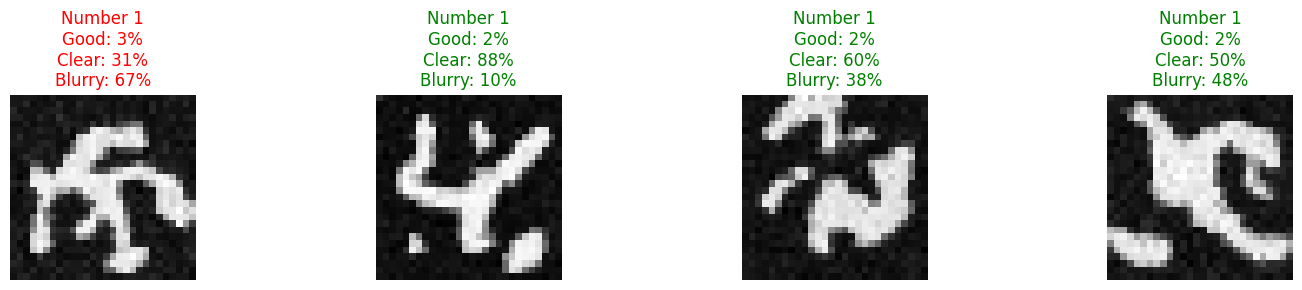


Generating and evaluating number 2...
Generating 4 versions of number 2...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


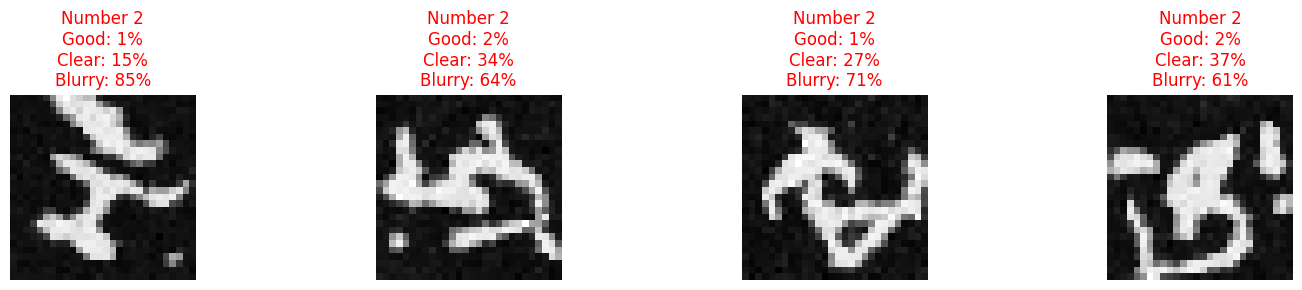


Generating and evaluating number 3...
Generating 4 versions of number 3...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


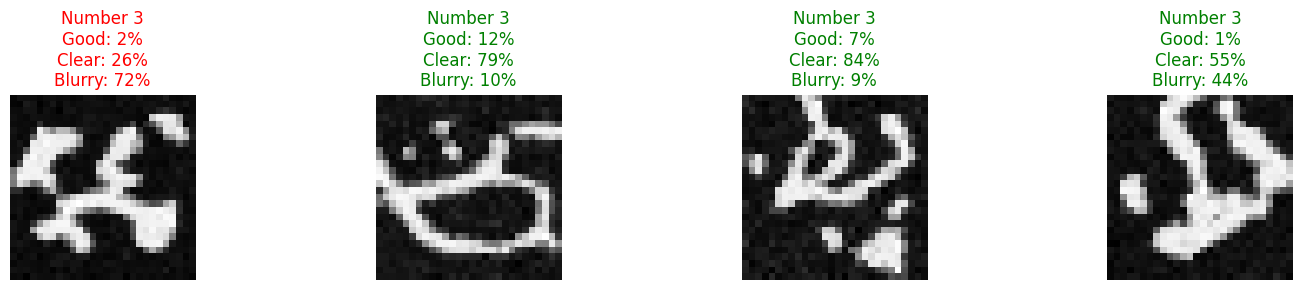


Generating and evaluating number 4...
Generating 4 versions of number 4...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


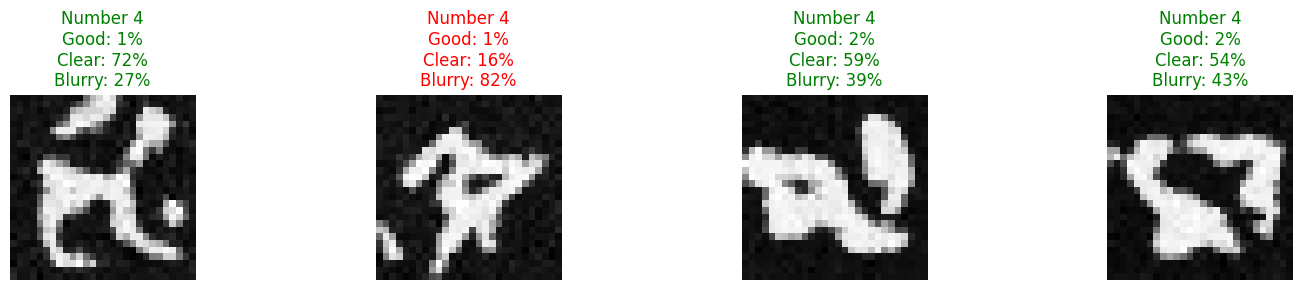


Generating and evaluating number 5...
Generating 4 versions of number 5...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


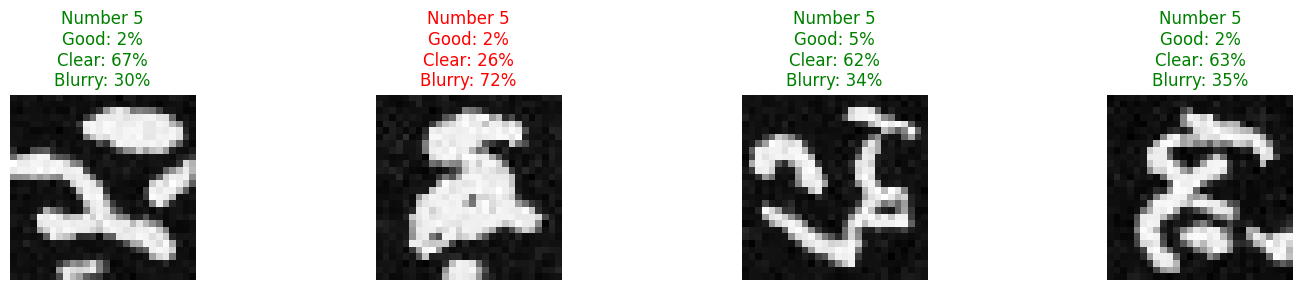


Generating and evaluating number 6...
Generating 4 versions of number 6...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


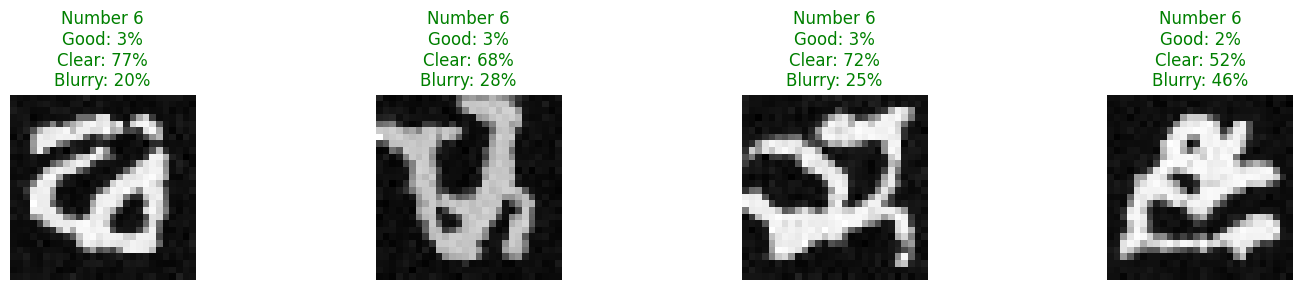


Generating and evaluating number 7...
Generating 4 versions of number 7...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


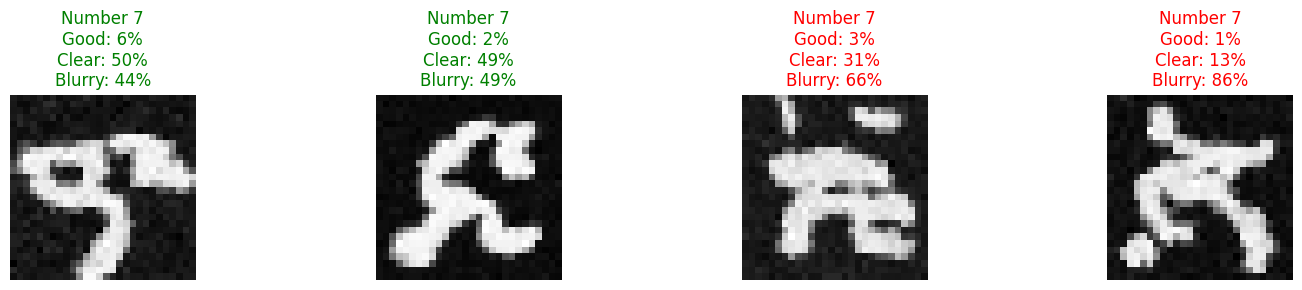


Generating and evaluating number 8...
Generating 4 versions of number 8...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


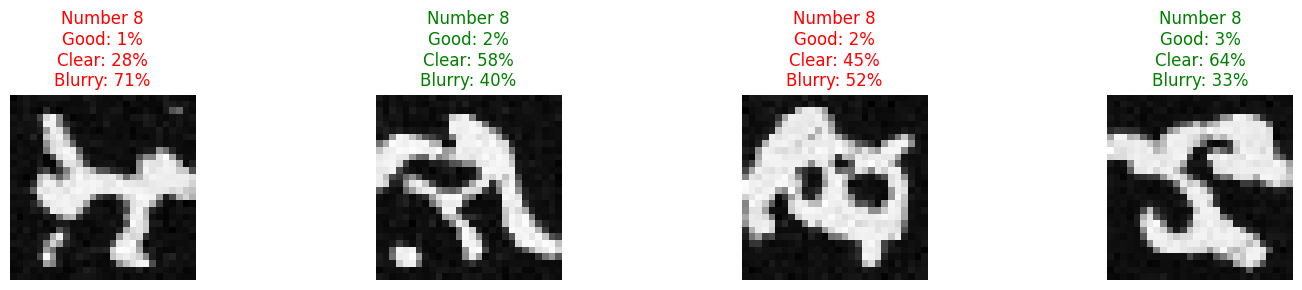


Generating and evaluating number 9...
Generating 4 versions of number 9...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed


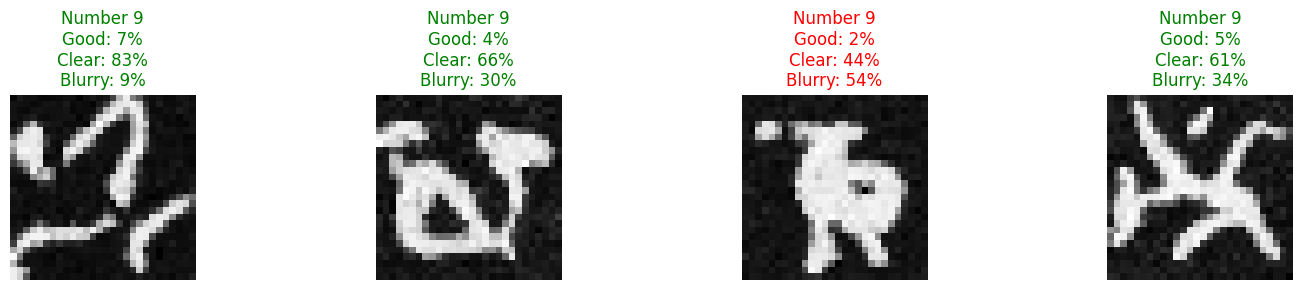


STUDENT ACTIVITY:
Try the code below to evaluate a larger sample of a specific digit
Generating 10 versions of number 6...
  Denoising step 19/99 completed
  Denoising step 39/99 completed
  Denoising step 59/99 completed
  Denoising step 79/99 completed
  Denoising step 99/99 completed
CLIP recognized 60.0% of the digits as good examples of 6


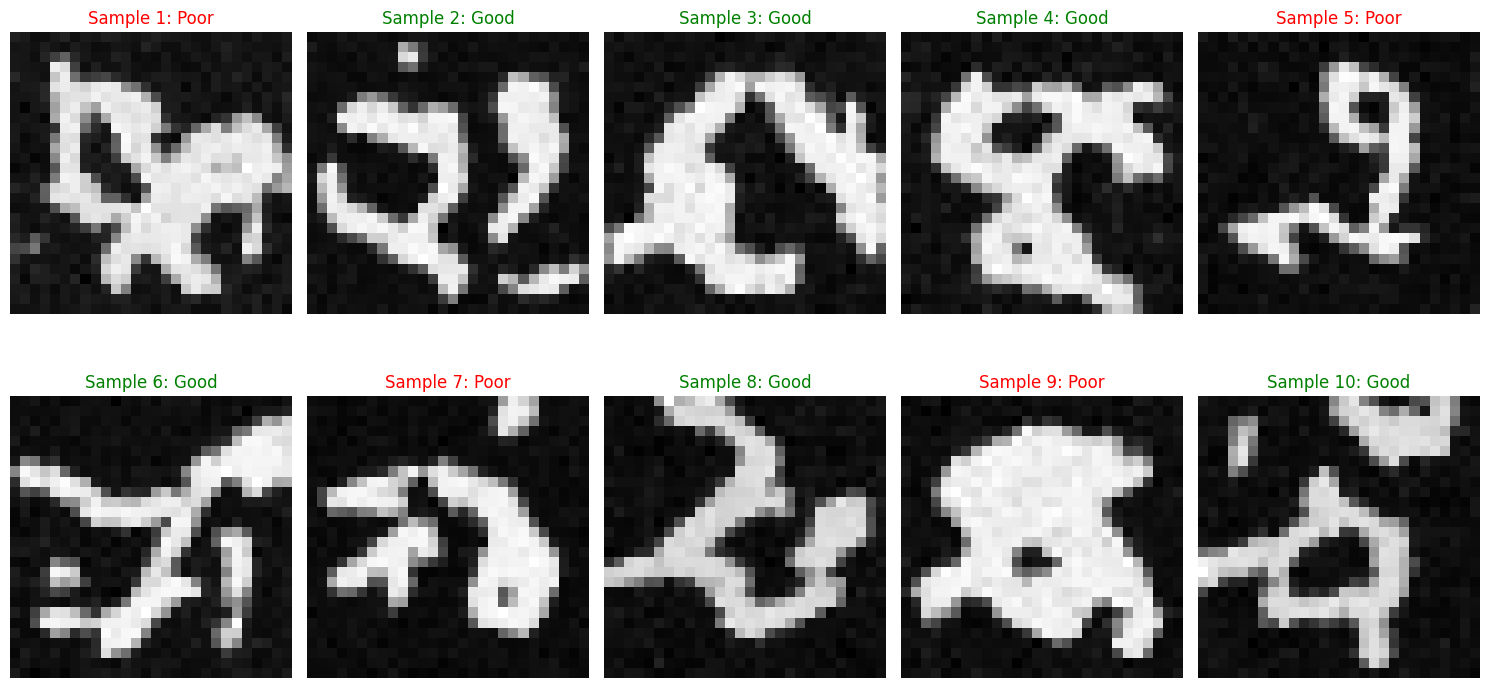

In [70]:
#==============================================================================
# Step 8: CLIP Model Loading and Evaluation Setup
#==============================================================================
# CLIP (Contrastive Language-Image Pre-training) is a neural network that connects
# vision and language. It was trained on 400 million image-text pairs to understand
# the relationship between images and their descriptions.
# We use it here as an "evaluation judge" to assess our generated images.

# Load CLIP model with error handling
try:
    # Load the ViT-B/32 CLIP model (Vision Transformer-based)
    clip_model, clip_preprocess = clip.load("ViT-B/32", device=device)
    print(f"✓ Successfully loaded CLIP model: {clip_model.visual.__class__.__name__}")
except Exception as e:
    print(f"❌ Failed to load CLIP model: {e}")
    clip_available = False
    # Instead of raising an error, we'll continue with degraded functionality
    print("CLIP evaluation will be skipped. Generated images will still be displayed but without quality scores.")

def evaluate_with_clip(images, target_number, max_batch_size=16):
    """
    Use CLIP to evaluate generated images by measuring how well they match textual descriptions.

    This function acts like an "automatic critic" for our generated digits by measuring:
    1. How well they match the description of a handwritten digit
    2. How clear and well-formed they appear to be
    3. Whether they appear blurry or poorly formed

    The evaluation process works by:
    - Converting our images to a format CLIP understands
    - Creating text prompts that describe the qualities we want to measure
    - Computing similarity scores between images and these text descriptions
    - Returning normalized scores (probabilities) for each quality

    Args:
        images (torch.Tensor): Batch of generated images [batch_size, channels, height, width]
        target_number (int): The specific digit (0-9) the images should represent
        max_batch_size (int): Maximum images to process at once (prevents GPU out-of-memory errors)

    Returns:
        torch.Tensor: Similarity scores tensor of shape [batch_size, 3] with scores for:
                     [good handwritten digit, clear digit, blurry digit]
                     Each row sums to 1.0 (as probabilities)
    """
    # If CLIP isn't available, return placeholder scores
    if not clip_available:
        print("⚠️ CLIP not available. Returning default scores.")
        # Equal probabilities (0.33 for each category)
        return torch.ones(len(images), 3).to(device) / 3

    try:
        # For large batches, we process in chunks to avoid memory issues
        # This is crucial when working with big images or many samples
        if len(images) > max_batch_size:
            all_similarities = []

            # Process images in manageable chunks
            for i in range(0, len(images), max_batch_size):
                print(f"Processing CLIP batch {i//max_batch_size + 1}/{(len(images)-1)//max_batch_size + 1}")
                batch = images[i:i+max_batch_size]

                # Use context managers for efficiency and memory management:
                # - torch.no_grad(): disables gradient tracking (not needed for evaluation)
                # - torch.cuda.amp.autocast(): uses mixed precision to reduce memory usage
                with torch.no_grad(), torch.cuda.amp.autocast():
                    batch_similarities = _process_clip_batch(batch, target_number)
                    all_similarities.append(batch_similarities)

                # Explicitly free GPU memory between batches
                # This helps prevent cumulative memory buildup that could cause crashes
                torch.cuda.empty_cache()

            # Combine results from all batches into a single tensor
            return torch.cat(all_similarities, dim=0)
        else:
            # For small batches, process all at once
            with torch.no_grad(), torch.cuda.amp.autocast():
                return _process_clip_batch(images, target_number)

    except Exception as e:
        # If anything goes wrong, log the error but don't crash
        print(f"❌ Error in CLIP evaluation: {e}")
        print(f"Traceback: {traceback.format_exc()}")
        # Return default scores so the rest of the notebook can continue
        return torch.ones(len(images), 3).to(device) / 3

def _process_clip_batch(images, target_number):
    """
    Core CLIP processing function that computes similarity between images and text descriptions.

    This function handles the technical details of:
    1. Preparing relevant text prompts for evaluation
    2. Preprocessing images to CLIP's required format
    3. Extracting feature embeddings from both images and text
    4. Computing similarity scores between these embeddings

    The function includes advanced error handling for GPU memory issues,
    automatically reducing batch size if out-of-memory errors occur.

    Args:
        images (torch.Tensor): Batch of images to evaluate
        target_number (int): The digit these images should represent

    Returns:
        torch.Tensor: Normalized similarity scores between images and text descriptions
    """
    try:
        # Create text descriptions (prompts) to evaluate our generated digits
        # We check three distinct qualities:
        # 1. If it looks like a handwritten example of the target digit
        # 2. If it appears clear and well-formed
        # 3. If it appears blurry or poorly formed (negative case)
        text_inputs = torch.cat([
            clip.tokenize(f"A handwritten number {target_number}"),
            clip.tokenize(f"A clear, well-written digit {target_number}"),
            clip.tokenize(f"A blurry or unclear number")
        ]).to(device)

        # Process images for CLIP, which requires specific formatting:

        # 1. Handle different channel configurations (dataset-dependent)
        if IMG_CH == 1:
            # CLIP expects RGB images, so we repeat the grayscale channel 3 times
            # For example, MNIST/Fashion-MNIST are grayscale (1-channel)
            images_rgb = images.repeat(1, 3, 1, 1)
        else:
            # For RGB datasets like CIFAR-10/CelebA, we can use as-is
            images_rgb = images

        # 2. Normalize pixel values to [0,1] range if needed
        # Different datasets may have different normalization ranges
        if images_rgb.min() < 0:  # If normalized to [-1,1] range
            images_rgb = (images_rgb + 1) / 2  # Convert to [0,1] range

        # 3. Resize images to CLIP's expected input size (224x224 pixels)
        # CLIP was trained on this specific resolution
        resized_images = F.interpolate(images_rgb, size=(224, 224),
                                      mode='bilinear', align_corners=False)

        # Extract feature embeddings from both images and text prompts
        # These are high-dimensional vectors representing the content
        image_features = clip_model.encode_image(resized_images)
        text_features = clip_model.encode_text(text_inputs)

        # Normalize feature vectors to unit length (for cosine similarity)
        # This ensures we're measuring direction, not magnitude
        image_features = image_features / image_features.norm(dim=-1, keepdim=True)
        text_features = text_features / text_features.norm(dim=-1, keepdim=True)

        # Calculate similarity scores between image and text features
        # The matrix multiplication computes all pairwise dot products at once
        # Multiplying by 100 scales to percentage-like values before applying softmax
        similarity = (100.0 * image_features @ text_features.T).softmax(dim=-1)

        return similarity

    except RuntimeError as e:
        # Special handling for CUDA out-of-memory errors
        if "out of memory" in str(e):
            # Free GPU memory immediately
            torch.cuda.empty_cache()

            # If we're already at batch size 1, we can't reduce further
            if len(images) <= 1:
                print("❌ Out of memory even with batch size 1. Cannot process.")
                return torch.ones(len(images), 3).to(device) / 3

            # Adaptive batch size reduction - recursively try with smaller batches
            # This is an advanced technique to handle limited GPU memory gracefully
            half_size = len(images) // 2
            print(f"⚠️ Out of memory. Reducing batch size to {half_size}.")

            # Process each half separately and combine results
            # This recursive approach will keep splitting until processing succeeds
            first_half = _process_clip_batch(images[:half_size], target_number)
            second_half = _process_clip_batch(images[half_size:], target_number)

            # Combine results from both halves
            return torch.cat([first_half, second_half], dim=0)

        # For other errors, propagate upward
        raise e

#==============================================================================
# CLIP Evaluation - Generate and Analyze Sample Digits
#==============================================================================
# This section demonstrates how to use CLIP to evaluate generated digits
# We'll generate examples of all ten digits and visualize the quality scores

try:
    for number in range(10):
        print(f"\nGenerating and evaluating number {number}...")

        # Generate 4 different variations of the current digit
        samples = generate_number(model, number, n_samples=4)

        # Evaluate quality with CLIP (without tracking gradients for efficiency)
        with torch.no_grad():
            similarities = evaluate_with_clip(samples, number)

        # Create a figure to display results
        plt.figure(figsize=(15, 3))

        # Show each sample with its CLIP quality scores
        for i in range(4):
            plt.subplot(1, 4, i+1)

            # Display the image with appropriate formatting based on dataset type
            if IMG_CH == 1:  # Grayscale images (MNIST, Fashion-MNIST)
                plt.imshow(samples[i][0].cpu(), cmap='gray')
            else:  # Color images (CIFAR-10, CelebA)
                img = samples[i].permute(1, 2, 0).cpu()  # Change format for matplotlib
                if img.min() < 0:  # Handle [-1,1] normalization
                    img = (img + 1) / 2  # Convert to [0,1] range
                plt.imshow(img)

            # Extract individual quality scores for display
            # These represent how confidently CLIP associates the image with each description
            good_score = similarities[i][0].item() * 100  # Handwritten quality
            clear_score = similarities[i][1].item() * 100  # Clarity quality
            blur_score = similarities[i][2].item() * 100   # Blurriness assessment

            # Color-code the title based on highest score category:
            # - Green: if either "good handwritten" or "clear" score is highest
            # - Red: if "blurry" score is highest (poor quality)
            max_score_idx = torch.argmax(similarities[i]).item()
            title_color = 'green' if max_score_idx < 2 else 'red'

            # Show scores in the plot title
            plt.title(f'Number {number}\nGood: {good_score:.0f}%\nClear: {clear_score:.0f}%\nBlurry: {blur_score:.0f}%',
                      color=title_color)
            plt.axis('off')

        plt.tight_layout()
        plt.show()
        plt.close()  # Properly close figure to prevent memory leaks

        # Clean up GPU memory after processing each number
        # This is especially important for resource-constrained environments
        torch.cuda.empty_cache()

except Exception as e:
    # Comprehensive error handling to help students debug issues
    print(f"❌ Error in generation and evaluation loop: {e}")
    print("Detailed error information:")
    import traceback
    traceback.print_exc()

    # Clean up resources even if we encounter an error
    if torch.cuda.is_available():
        print("Clearing GPU cache...")
        torch.cuda.empty_cache()

#==============================================================================
# STUDENT ACTIVITY: Exploring CLIP Evaluation
#==============================================================================
# This section provides code templates for students to experiment with
# evaluating larger batches of generated digits using CLIP.

print("\nSTUDENT ACTIVITY:")
print("Try the code below to evaluate a larger sample of a specific digit")
# Example: Generate and evaluate 10 examples of the digit 6
digit = 6
samples = generate_number(model, digit, n_samples=10)
similarities = evaluate_with_clip(samples, digit)

# Calculate what percentage of samples CLIP considers "good quality"
good_or_clear = (similarities[:,0] + similarities[:,1] > similarities[:,2]).float().mean()
print(f"CLIP recognized {good_or_clear.item()*100:.1f}% of the digits as good examples of {digit}")

# Display a grid of samples with their quality scores
plt.figure(figsize=(15, 8))
for i in range(len(samples)):
    plt.subplot(2, 5, i+1)
    plt.imshow(samples[i][0].cpu(), cmap='gray')
    quality = "Good" if similarities[i,0] + similarities[i,1] > similarities[i,2] else "Poor"
    plt.title(f"Sample {i+1}: {quality}", color='green' if quality == "Good" else 'red')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Assessment Questions

Now that you've completed the exercise, answer these questions include explanations, observations, and your analysis
Support your answers with specific examples from your experiments:

### 1. Understanding Diffusion
- Explain what happens during the forward diffusion process, using your own words and referencing the visualization examples from your notebook.


 Forward diffusion is comparable to gradually burying a picture in snow. At each stage, you add a small amount of random noise to a clear image. After a certain number of steps, the image is just static and completely unrecognizable. This is shown in the notebook visualizations as the image progressively gets grainier until no digit is visible.


- Why do we add noise gradually instead of all at once? How does this affect the learning process?

If you added all the noise at once, the model would just see random static with no connection to the original image there'd be nothing to learn from. By doing it gradually, the model learns small steps of how noise relates to it.

- Look at the step-by-step visualization - at what point (approximately what percentage through the denoising process) can you first recognize the image? Does this vary by image?

 At 20–30% of the denoising process, I started to see rough shapes, and by 50%, the digit is recognizable. This varies by digit; simpler digits, like 1 and 7, typically appear earlier vs more complex like 8 and 9,

### 2. Model Architecture
- Why is the U-Net architecture particularly well-suited for diffusion models? What advantages does it provide over simpler architectures?

U-Net works like  a zoom-in/zoom-out system. It first compresses the image, then expands it back up to reconstruct fine details. Simpler architectures can only function at one scale; they would either lose sight of the big picture or overlook fine details. U-Net manages both concurrently.

- What are skip connections and why are they important? Explain them in relations to our model


Skip connections are shortcuts that pass information from the compression downsampling side directly to the expansion upsampling side. In the model when torch.cat runs in Upblock, it combines the upsampled features with the original features from the same level. Without the skips, fine details can get lost/ unrecoverable.

- Describe in detail how our model is conditioned to generate specific images. How does the class conditioning mechanism work?

 To generate a conditioning embedding, our model takes the digit label 0 to 9, transforms it into a one-hot vector, and then runs it through an EmbedBlock. At the bottleneck, this embedding is directly applied to the image features. The model can function without a class label because the c_mask determines whether conditioning is applied.


### 3. Training Analysis (20 points)
- What does the loss value tell of your model tell us?

The loss shows how far off my model was from the predicted noise vs the actual noise added.


- How did the quality of  your  generated images change change throughout the training process?

Early testing had blurry blobs. By the middle testing rough digit shapes emerge. By the final epochs the digits become cleaner and more distinct.

- Why do we need the time embedding in diffusion models? How does it help the model understand where it is in the denoising process?

Without time embedding, the denoising strenght would be used in every step which will hash out the picture. The model knows precisely where it is in the process thanks to the time embedding, which allows it to make necessary adjustments.

### 4. CLIP Evaluation (20 points)
- What do the CLIP scores tell you about your generated images? Which images got  the highest and lowest quality scores?

CLIP scores indicate how well my generated images match a description of a human text. Oddly, it failed more on 7 vs 8, 9, and 3 which i thought would be more hard to pick up.

- Develop a hypothesis explaining why certain images might be easier or harder for the model to generate convincingly.

I think it something to do with symmetry and how nicely or poorly said numbers edges are.

- How could CLIP scores be used to improve the diffusion model's generation process? Propose a specific technique.

One method is CLIP-guided diffusion, which involves computing the gradient of the CLIP score with respect to the image at each denoising step in addition to using the model's prediction.


### 5. Practical Applications (20 points)
- How could this type of model be useful in the real world?

I can see it being useful for making up fonts and helping artists as creative tools.

- What are the limitations of our current model?

I used the lowest resolution and trained on a small dataset.

- If you were to continue developing this project, what three specific improvements would you make and why?

 - paid colab version

 - train the model with and without class labels to control the generation speed

 - Increase the number of channels and attentions layers to help laern more complex features

### Citations

Ho et al. (2020)  Denoising Diffusion Probabilistic Models (DDPM)

Ronneberger et al. (2015) U-Net: Convolutional Networks for Biomedical Image Segmentation

Radford et al. (2021) Learning Transferable Visual Models From Natural Language Supervision


Deliverables:
1. A PDF copy of your notebook with
    - Complete code, outputs, and generated images
    - Include all experiment results, training plots, and generated samples
    - CLIP evaluation scores of ythe images you generated
    - Answers and any interesting findings from the bonus challenges